In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

In [2]:
df = pd.read_csv("<your path for final dataset>", sep=None, engine="python")
df.shape

(608304, 45)

In [3]:
y = df["is_alarm"]
X = df.drop(["is_alarm"], axis=1)
X = X.select_dtypes(include=[np.number]) 

# REMOVE NAN

data = pd.concat([X, y], axis=1)
data = data.dropna()
X = data.drop("is_alarm", axis=1)
y = data["is_alarm"]
feature_names = X.columns.tolist()
print("Dataset shape after removing NaN:", data.shape)
print("Number of features:", len(feature_names))

Dataset shape after removing NaN: (21625, 31)
Number of features: 30


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tscv = TimeSeriesSplit(n_splits=5)
splits = []

In [5]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

best_model = None
best_score = 0
best_params = None

TRAIN WITH CROSS-VALIDATION

In [6]:
best_model = None
best_score = -1
best_params = None


for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for m in param_grid["min_samples_split"]:
            fold_scores = []
            for train_index, test_index in tscv.split(X_scaled):
                X_train_f, X_test_f = X_scaled[train_index], X_scaled[test_index]
                y_train_f, y_test_f = y.iloc[train_index], y.iloc[test_index]
                
                model = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_split=m,
                    random_state=42,
                    class_weight="balanced"
                )
                model.fit(X_train_f, y_train_f)
                score = model.score(X_test_f, y_test_f)
                fold_scores.append(score)
            
            mean_score = np.mean(fold_scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = {"n_estimators": n, "max_depth": d, "min_samples_split": m}

print("\nBest Hyperparameters (based on mean CV score):", best_params)
print("Best Mean Accuracy across all folds:", best_score)


Best Hyperparameters (based on mean CV score): {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
Best Mean Accuracy across all folds: 0.9778024417314095


FINAL MODEL

In [7]:
# Evaluate on ALL folds
y_test_all = []
y_pred_all = []
y_proba_all = []
fold_models = []

for fold_idx, (train_index, test_index) in enumerate(tscv.split(X_scaled)):
    X_train_f, X_test_f = X_scaled[train_index], X_scaled[test_index]
    y_train_f, y_test_f = y.iloc[train_index], y.iloc[test_index]
    
    model_f = RandomForestClassifier(**best_params, random_state=42, class_weight='balanced')
    model_f.fit(X_train_f, y_train_f)
    
    y_pred_f = model_f.predict(X_test_f)
    y_proba_f = model_f.predict_proba(X_test_f)[:, 1]
    
    y_test_all.append(y_test_f)
    y_pred_all.append(y_pred_f)
    y_proba_all.append(y_proba_f)
    fold_models.append(model_f)
    print(f"Fold {fold_idx+1}: train={len(train_index)}, test={len(test_index)}")

y_test_agg = np.concatenate([yt.values for yt in y_test_all])
y_pred_agg = np.concatenate(y_pred_all)
y_proba_agg = np.concatenate(y_proba_all)

final_model = fold_models[-1]

print(f"\nTotal aggregated samples: {len(y_test_agg)}")

Fold 1: train=3605, test=3604
Fold 2: train=7209, test=3604
Fold 3: train=10813, test=3604
Fold 4: train=14417, test=3604
Fold 5: train=18021, test=3604

Total aggregated samples: 18020


METRICS

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Per-fold metrics for robustness analysis
print("Per-Fold Metrics:")
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 54)

fold_metrics = []
for i, (yt, yp) in enumerate(zip(y_test_all, y_pred_all)):
    acc = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec = recall_score(yt, yp, zero_division=0)
    f1 = f1_score(yt, yp, zero_division=0)
    fold_metrics.append({'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f"{i+1:<6} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("\nAggregated Metrics (Mean +/- Std across all folds):")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    vals = [m[metric] for m in fold_metrics]
    print(f"  {metric.capitalize():<10}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

print("\nOverall Metrics (on all aggregated predictions):")
print(f"  Accuracy:  {accuracy_score(y_test_agg, y_pred_agg):.4f}")
print(f"  Precision: {precision_score(y_test_agg, y_pred_agg, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test_agg, y_pred_agg, zero_division=0):.4f}")
print(f"  F1-score:  {f1_score(y_test_agg, y_pred_agg, zero_division=0):.4f}")

Per-Fold Metrics:
Fold   Accuracy     Precision    Recall       F1          
------------------------------------------------------
1      0.9750       0.9750       1.0000       0.9874      
2      0.9834       0.9834       1.0000       0.9916      
3      0.9842       0.9842       1.0000       0.9920      
4      0.9767       0.9767       1.0000       0.9882      
5      0.9698       0.9698       1.0000       0.9846      

Aggregated Metrics (Mean +/- Std across all folds):
  Accuracy  : 0.9778 +/- 0.0054
  Precision : 0.9778 +/- 0.0054
  Recall    : 1.0000 +/- 0.0000
  F1        : 0.9888 +/- 0.0028

Overall Metrics (on all aggregated predictions):
  Accuracy:  0.9778
  Precision: 0.9778
  Recall:    1.0000
  F1-score:  0.9888


CONFUSION MATRIX


Confusion Matrix (aggregated across all folds):
 [[    0   400]
 [    0 17620]]

Classification Report (aggregated across all folds):
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       400
         1.0       0.98      1.00      0.99     17620

    accuracy                           0.98     18020
   macro avg       0.49      0.50      0.49     18020
weighted avg       0.96      0.98      0.97     18020


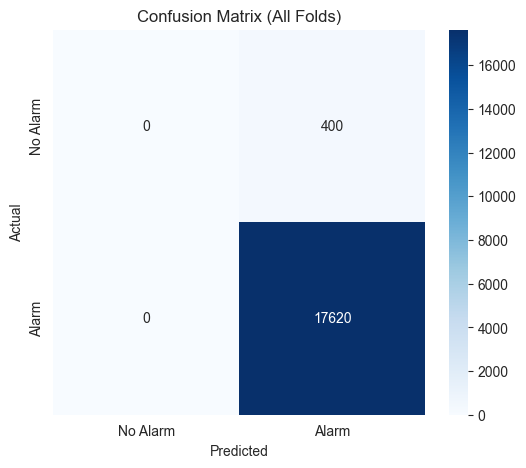

In [9]:
cm = confusion_matrix(y_test_agg, y_pred_agg)
print("\nConfusion Matrix (aggregated across all folds):\n", cm)
print("\nClassification Report (aggregated across all folds):\n",
      classification_report(y_test_agg, y_pred_agg, zero_division=0))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Alarm","Alarm"],
            yticklabels=["No Alarm","Alarm"])
plt.title("Confusion Matrix (All Folds)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

FEATURE IMPORTANCE

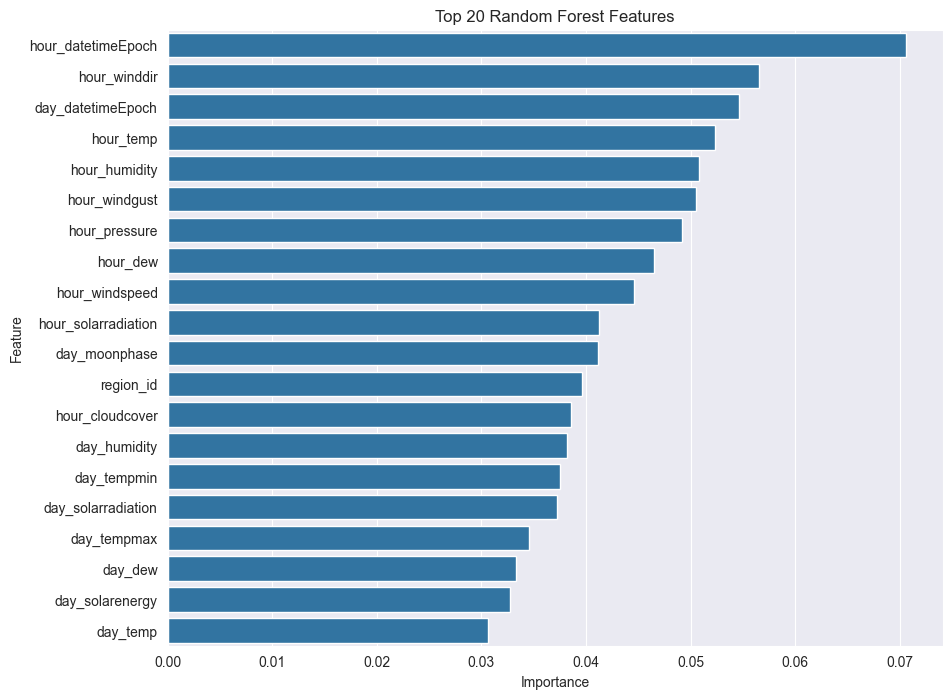

In [10]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
top20 = importance.head(20)

plt.figure(figsize=(10,8))
sns.barplot(data=top20, x="Importance", y="Feature")
plt.title("Top 20 Random Forest Features")
plt.show()

ROC Curve

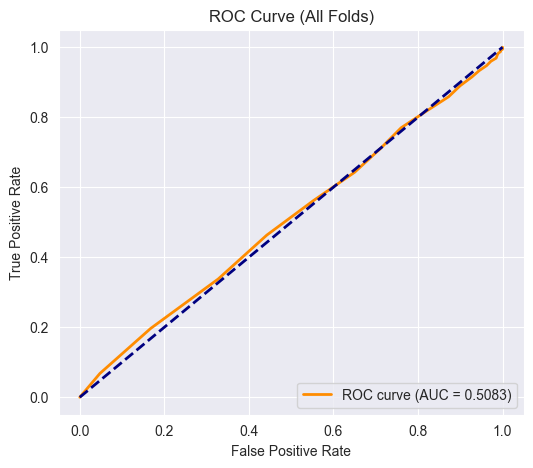

In [11]:
fpr, tpr, thresholds = roc_curve(y_test_agg, y_proba_agg)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Folds)")
plt.legend(loc="lower right")
plt.show()

Precision-Recall Curve

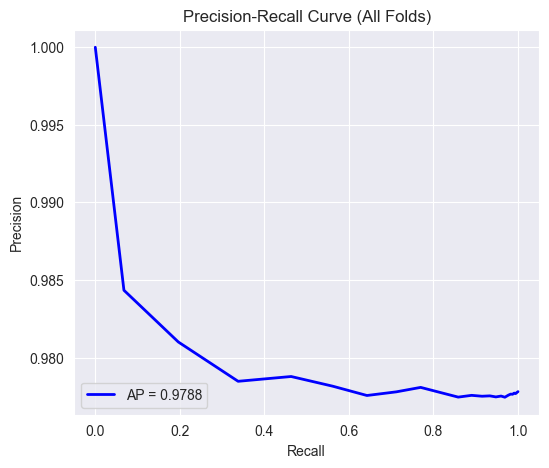

In [12]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test_agg, y_proba_agg)
avg_prec = average_precision_score(y_test_agg, y_proba_agg)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'AP = {avg_prec:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (All Folds)")
plt.legend(loc="lower left")
plt.show()